# Preprocessing Phase
- This phase will cover the cleaning of dataset for use in modelling.
- Dropped rows with null values in `median_days_open` and `salary_premium_pct` for linear regression modeling.
- Preparing dataset: encoding categoricals, scaling numeric features.
- The process will split the raw dataset into two datasets, one for insights and one for modelling purposes.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [11]:
DATASET_FILEPATH = '../../dataset/raw/'
DATASET_FILENAME = 'skill-scarcity-index.csv'
PROCESSED_DATASET_FILEPATH = '../../dataset/processed/'
FIGURES_FILEPATH = '../../figures/preprocessing/'

# Pandas import
df = pd.read_csv(DATASET_FILEPATH+DATASET_FILENAME, index_col=0).reset_index(drop=True)

In [12]:
# First 10 Rows
df.head(10)

,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
0,ai,A/B Testing,115,4.7,1.0,3.9,2.0,49.2
1,ai,Agile / Scrum,63,2.6,1.0,42.5,14.0,62.9
2,ai,AI Agents,153,6.3,NaN,45.5,5.9,72.0
3,ai,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0
4,ai,Airflow,54,2.2,9.0,-38.7,16.2,57.2
5,ai,AWS,259,10.6,0.0,-29.2,11.2,31.0
6,ai,Azure,221,9.0,0.0,-46.9,19.5,28.3
7,ai,BigQuery,43,1.8,4.0,NaN,22.2,75.5
8,ai,C#,42,1.7,0.0,-31.5,7.2,25.0
9,ai,C++,66,2.7,1.0,-10.9,18.0,60.4


In [13]:
# Drop Nulls on median_days_open and salary_premium_pct
df = df.dropna(subset=['median_days_open', 'salary_premium_pct'])

In [14]:
# Show rows that have null values in the 'median_days_open' column
null_median_days = df[df['median_days_open'].isnull()]
print(f"Number of rows with Null Values: {len(null_median_days)}")
null_median_days

Number of rows with Null Values: 0


,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score


In [15]:
# Show rows that have null values in the 'salary_premium_pct' 
null_salary_premium_pct = df[df['salary_premium_pct'].isnull()]
print(f"Number of rows with Null Values: {len(null_salary_premium_pct)}")
null_salary_premium_pct

Number of rows with Null Values: 0


,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score


FileNotFoundError: [Errno 2] No such file or directory: '../../figures/preprocessing//preprocessing/median_days_open_distribution_log.png'

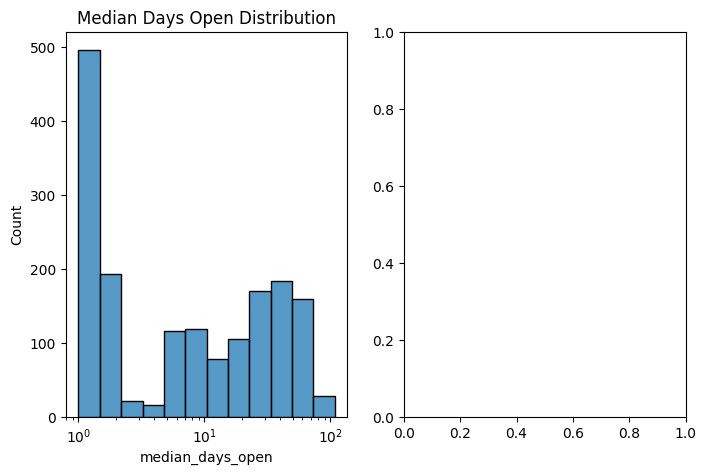

In [16]:
# Histogram Plotting 
fig, ax = plt.subplots(1,2,figsize=(8,5))

# log scaled histogram for demand count
sns.histplot(data=df, x='median_days_open', ax=ax[0], log_scale=True)
ax[0].set_title('Median Days Open Distribution')
plt.savefig(FIGURES_FILEPATH + '/preprocessing/median_days_open_distribution_log.png', dpi=300, bbox_inches='tight')

sns.histplot(data=df, x='salary_premium_pct', ax=ax[1], log_scale=True)
ax[1].set_title('Salary Premium Percentage Distribution')
plt.savefig(FIGURES_FILEPATH + '/salary_premium_pct_distribution_log.png', dpi=300, bbox_inches='tight')

In [ ]:
# Log transform columns
df['log_median_days_open'] = np.log1p(df['median_days_open'])

We log transform the `median_days_open` column to fix the right skewness present in our data.
Log transformation compresses large values while pulling out the low ends.

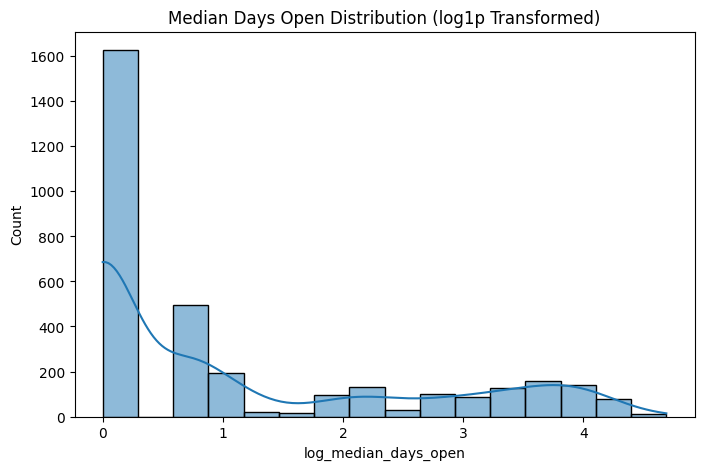

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8,5))

# log scaled histogram for demand count
sns.histplot(data=df, x='log_median_days_open', ax=ax, kde=True)
ax.set_title('Median Days Open Distribution (log1p Transformed)')
plt.savefig(FIGURES_FILEPATH + '/log1p_median_days_open_distribution_log.png', dpi=300, bbox_inches='tight')

In [ ]:
# Final Checks
null_values = df.isnull().sum()
print(f"Null Values in Each Column:\n{null_values}")

Null Values in Each Column:
category                0
skill_name              0
demand_count            0
demand_pct              0
median_days_open        0
salary_premium_pct      0
repost_rate_pct         0
scarcity_score          0
log_median_days_open    0
dtype: int64


In [ ]:
# Drop categorical columns that are not needed for modeling
model_features = [
    'scarcity_score', 
    'salary_premium_pct', 
    'repost_rate_pct', 
    'demand_count', 
    'median_days_open',
    'log_median_days_open'
]

df_model = df[model_features]
print(f"DF Shape: {df_model.shape}")
# Export to csv
df_model.to_csv(PROCESSED_DATASET_FILEPATH+'model_dataset.csv', index=False)

DF Shape: (3316, 6)


Code below will create new dataset for processed dataset under `/datasets/processed/`.

In [17]:
# Load Separate DF
df1 = pd.read_csv(DATASET_FILEPATH+DATASET_FILENAME).reset_index(drop=True)

In [18]:
# Convert snapshot_date to year, day and month columns
df1['snapshot_date'] = pd.to_datetime(df1['snapshot_date'])
df1['year'] = df1['snapshot_date'].dt.year
df1['day'] = df1['snapshot_date'].dt.day
df1['month'] = df1['snapshot_date'].dt.month_name()

print(f"DF Shape: {df1.shape}")
df1.head(10)

DF Shape: (4933, 12)


,snapshot_date,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score,year,day,month
0,2026-07-12,ai,A/B Testing,115,4.7,1.0,3.9,2.0,49.2,2026,12,July
1,2026-07-12,ai,Agile / Scrum,63,2.6,1.0,42.5,14.0,62.9,2026,12,July
2,2026-07-12,ai,AI Agents,153,6.3,NaN,45.5,5.9,72.0,2026,12,July
3,2026-07-12,ai,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0,2026,12,July
4,2026-07-12,ai,Airflow,54,2.2,9.0,-38.7,16.2,57.2,2026,12,July
5,2026-07-12,ai,AWS,259,10.6,0.0,-29.2,11.2,31.0,2026,12,July
6,2026-07-12,ai,Azure,221,9.0,0.0,-46.9,19.5,28.3,2026,12,July
7,2026-07-12,ai,BigQuery,43,1.8,4.0,NaN,22.2,75.5,2026,12,July
8,2026-07-12,ai,C#,42,1.7,0.0,-31.5,7.2,25.0,2026,12,July
9,2026-07-12,ai,C++,66,2.7,1.0,-10.9,18.0,60.4,2026,12,July


In [ ]:
# List values with null,space, or * values
missing_or_asterisk_df = df1[
    df1['category'].isna() | 
    (df1['category'] == '*') | 
    (df1['category'] == '')
]

with pd.option_context('display.max_rows', None):
    print(missing_or_asterisk_df)

Empty DataFrame
Columns: [snapshot_date, category, skill_name, demand_count, demand_pct, median_days_open, salary_premium_pct, repost_rate_pct, scarcity_score, year, day, month]
Index: []


In [ ]:
# Categorize Rows that have vague categories
skill_categories = {
    # --- AI, Machine Learning & Data Science ---
    "AI Agents": "AI / ML & Data Science",
    "AI Coding Tools": "AI / ML & Data Science",
    "Deep Learning": "AI / ML & Data Science",
    "Fine-tuning": "AI / ML & Data Science",
    "Hugging Face": "AI / ML & Data Science",
    "LangChain": "AI / ML & Data Science",
    "LLMs / GenAI": "AI / ML & Data Science",
    "LLM APIs": "AI / ML & Data Science",
    "Machine Learning": "AI / ML & Data Science",
    "MLflow": "AI / ML & Data Science",
    "NLP": "AI / ML & Data Science",
    "NumPy": "AI / ML & Data Science",
    "Pandas": "AI / ML & Data Science",
    "Polars": "AI / ML & Data Science",
    "Prompt Engineering": "AI / ML & Data Science",
    "PyTorch": "AI / ML & Data Science",
    "RAG": "AI / ML & Data Science",
    "SageMaker": "AI / ML & Data Science",
    "scikit-learn": "AI / ML & Data Science",
    "Statistical Analysis": "AI / ML & Data Science",
    "TensorFlow": "AI / ML & Data Science",
    "Vector Databases": "AI / ML & Data Science",
    "vLLM": "AI / ML & Data Science",
    "XGBoost": "AI / ML & Data Science",
    # --- Data Engineering & Architecture ---
    "Airbyte": "Data Engineering",
    "Airflow": "Data Engineering",
    "Apache Iceberg": "Data Engineering",
    "ClickHouse": "Data Engineering",
    "Dagster": "Data Engineering",
    "Data Modeling": "Data Engineering",
    "Data Observability": "Data Engineering",
    "Data Pipeline": "Data Engineering",
    "Databricks": "Data Engineering",
    "dbt": "Data Engineering",
    "DuckDB": "Data Engineering",
    "ETL": "Data Engineering",
    "Fivetran": "Data Engineering",
    "Flink": "Data Engineering",
    "Informatica": "Data Engineering",
    "Kafka": "Data Engineering",
    "Prefect": "Data Engineering",
    "Redshift": "Data Engineering",
    "Snowflake": "Data Engineering",
    "Spark": "Data Engineering",
    "SSIS": "Data Engineering",
    "Trino": "Data Engineering",
    # --- Cloud, Infrastructure & DevOps ---
    "Ansible": "Cloud & DevOps",
    "ArgoCD": "Cloud & DevOps",
    "AWS": "Cloud & DevOps",
    "Azure": "Cloud & DevOps",
    "CI/CD": "Cloud & DevOps",
    "Datadog": "Cloud & DevOps",
    "Docker": "Cloud & DevOps",
    "GCP": "Cloud & DevOps",
    "Grafana": "Cloud & DevOps",
    "Helm": "Cloud & DevOps",
    "Kubernetes": "Cloud & DevOps",
    "Linux": "Cloud & DevOps",
    "Prometheus": "Cloud & DevOps",
    "Pulumi": "Cloud & DevOps",
    "Terraform": "Cloud & DevOps",
    # --- Software Engineering & Programming ---
    "Bash": "Software Engineering",
    "C#": "Software Engineering",
    "C++": "Software Engineering",
    "Django": "Software Engineering",
    "FastAPI": "Software Engineering",
    "Flask": "Software Engineering",
    "Go": "Software Engineering",
    "Java": "Software Engineering",
    "Jupyter": "Software Engineering",
    "Kotlin": "Software Engineering",
    "MCP": "Software Engineering",
    "Microservices": "Software Engineering",
    "PHP": "Software Engineering",
    "Python": "Software Engineering",
    "REST API": "Software Engineering",
    "Ruby": "Software Engineering",
    "Rust": "Software Engineering",
    "Scala": "Software Engineering",
    "Spring": "Software Engineering",
    "Swift": "Software Engineering",
    "System Design": "Software Engineering",
    # --- Web & Frontend Development ---
    "Angular": "Web Development",
    "GraphQL": "Web Development",
    "JavaScript": "Web Development",
    "Next.js": "Web Development",
    "Node.js": "Web Development",
    "React": "Web Development",
    "Svelte": "Web Development",
    "TypeScript": "Web Development",
    "Vue": "Web Development",
    # --- Databases & Backend Storage ---
    "BigQuery": "Databases",
    "Cassandra": "Databases",
    "DynamoDB": "Databases",
    "Elasticsearch": "Databases",
    "Firebase": "Databases",
    "MongoDB": "Databases",
    "MySQL": "Databases",
    "Oracle": "Databases",
    "PostgreSQL": "Databases",
    "Redis": "Databases",
    "SQL": "Databases",
    "Supabase": "Databases",
    # --- Business Intelligence & Analytics ---
    "A/B Testing": "BI & Analytics",
    "Alteryx": "BI & Analytics",
    "Amplitude": "BI & Analytics",
    "Excel": "BI & Analytics",
    "Google Analytics": "BI & Analytics",
    "Looker": "BI & Analytics",
    "Metabase": "BI & Analytics",
    "Mixpanel": "BI & Analytics",
    "Power BI": "BI & Analytics",
    "Qlik": "BI & Analytics",
    "SAS": "BI & Analytics",
    "Segment": "BI & Analytics",
    "Streamlit": "BI & Analytics",
    "Superset": "BI & Analytics",
    "Tableau": "BI & Analytics",
    # --- Cybersecurity & Governance ---
    "AWS Security": "Cybersecurity",
    "Burp Suite": "Cybersecurity",
    "CISSP": "Cybersecurity",
    "Incident Response": "Cybersecurity",
    "OWASP": "Cybersecurity",
    "Penetration Testing": "Cybersecurity",
    "SIEM": "Cybersecurity",
    "SOC 2": "Cybersecurity",
    "Zero Trust": "Cybersecurity",
    # --- Enterprise & ERP / CRM Platforms ---
    "Dynamics 365": "Enterprise Platforms",
    "Microsoft Fabric": "Enterprise Platforms",
    "MuleSoft": "Enterprise Platforms",
    "NetSuite": "Enterprise Platforms",
    "Salesforce": "Enterprise Platforms",
    "SAP": "Enterprise Platforms",
    "ServiceNow": "Enterprise Platforms",
    "Workday": "Enterprise Platforms",
    "Workflow Automation": "Enterprise Platforms",
    # --- Product, Design & Agile Management ---
    "Agile / Scrum": "Product & Management",
    "Figma": "Product & Management",
    "Jira": "Product & Management",
    "Linear": "Product & Management",
    "Prototyping": "Product & Management",
    "Stakeholder Mgmt": "Product & Management",
    "User Research": "Product & Management",
}

# Apply mapping to skill_categories
df["category"] = df["skill_name"].map(skill_categories).fillna("Other")
df["category"].value_counts()

In [ ]:
# Export to csv
df1.to_csv(PROCESSED_DATASET_FILEPATH+'skills-scarcity-index-processed.csv', index=False)

This concludes the **Preprocessing phase**, next is `03_hypothesis_testing.ipynb`